# Label-Image API: Single-label vs Multi-label on a 3D Segmentation

This notebook demonstrates `minkowski_tensors_from_label_image()` on a real 3D fluorescence microscopy segmentation from the **Allen Cell Collection**.

The image shows a hiPSC undergoing **Anaphase/Telophase/Cytokinesis (Early)**: the cell is mid-division, with two daughter nuclei separating inside a cell body.

Data source: [Allen Cell & Structure Segmenter](https://open.quiltdata.com/b/allencell/packages/aics/mitotic_annotation)

Voxel size: **0.108333 µm** (isotropic), from [Viana et al. 2020](https://www.biorxiv.org/content/10.1101/2020.12.08.415562v1.full)

**Requires:** `tifffile` (`pip install tifffile`)

---

We walk through three labelling strategies on the same segmentation to show how the choice of labels changes what Minkowski tensors measure:

| Case | Label image | What is measured |
|------|-------------|------------------|
| 1 | Cell body as a single label | Whole-cell morphometry |
| 2 | Nuclei = label 1, cell body = label 2 | Per-compartment morphometry |
| 3 | Each nuclear object as a separate label | Per-nuclear object anisotropy |

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import ndimage
import tifffile
import pykarambola as pk

## 1. Load the segmentation

The file is a 2-channel OME-TIFF with shape `(C, Z, Y, X)`:
- **Channel 0** — nuclei (binary mask, 3 connected components)
- **Channel 1** — cell body (binary mask, 1 connected component)

In [54]:
seg = tifffile.imread('../dataset/multilabel_test/f5d35d71_segmentation.ome.tif')
print(f'Shape: {seg.shape}  dtype: {seg.dtype}')  # (2, Z, Y, X)

nuclei_mask = (seg[0] > 0).astype(np.uint8)   # channel 0: nuclei
cell_mask   = (seg[1] > 0).astype(np.uint8)   # channel 1: cell body

Z, Y, X = nuclei_mask.shape
# mid_z = Z // 2
mid_z = 48  # manually set mid_z for visualization
print(f'Volume shape: Z={Z}, Y={Y}, X={X}  |   Z-slice: {mid_z}')

# Isotropic voxel size from Viana et al. 2020 (bioRxiv 2020.12.08.415562)
voxel_size_um = 0.108333  # µm per voxel
print(f'\nPhysical dimensions: {Z*voxel_size_um:.2f} × {Y*voxel_size_um:.2f} × {X*voxel_size_um:.2f} µm  (Z × Y × X)')

Shape: (2, 144, 287, 373)  dtype: uint8
Volume shape: Z=144, Y=287, X=373  |   Z-slice: 48

Physical dimensions: 15.60 × 31.09 × 40.41 µm  (Z × Y × X)


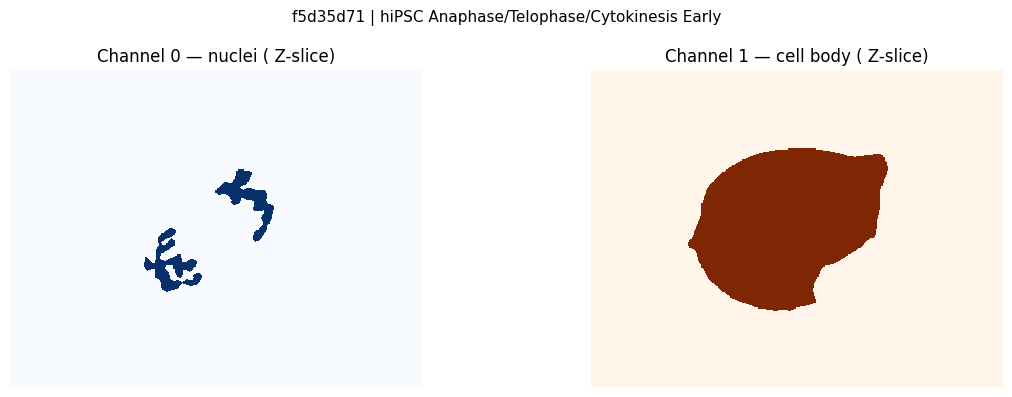

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(nuclei_mask[mid_z], cmap='Blues', interpolation='nearest')
axes[0].set_title('Channel 0 — nuclei ( Z-slice)')
axes[0].axis('off')
axes[1].imshow(cell_mask[mid_z], cmap='Oranges', interpolation='nearest')
axes[1].set_title('Channel 1 — cell body ( Z-slice)')
axes[1].axis('off')
plt.suptitle('f5d35d71 | hiPSC Anaphase/Telophase/Cytokinesis Early', fontsize=11)
plt.tight_layout()
plt.show()

## Case 1 — Whole-cell morphometry

Treat the entire cell body as a **single label**. The returned tensors describe the whole cell as one object.

This is the simplest use case: one binary mask → one set of Minkowski tensors.

In [56]:
label_case1 = cell_mask.astype(int)  # 0 = background, 1 = cell

results_case1 = pk.minkowski_tensors_from_label_image(label_case1, compute="all")
r = results_case1[1]

print('Case 1 — whole cell body')
print(f'  Volume (w000):             {r["w000"] * voxel_size_um**3:.1f} µm³')
print(f'  Surface area (w100):       {r["w100"] * voxel_size_um**2:.1f} µm²')
print(f'  Euler characteristic:      {r["w300"]:.4f}')
print(f'  Anisotropy (w020_beta):    {r["w020_beta"]:.4f}  (1 = isotropic, 0 = maximally anisotropic)')

Case 1 — whole cell body
  Volume (w000):             3096.6 µm³
  Surface area (w100):       499.4 µm²
  Euler characteristic:      4.1888
  Anisotropy (w020_beta):    0.2773  (1 = isotropic, 0 = maximally anisotropic)


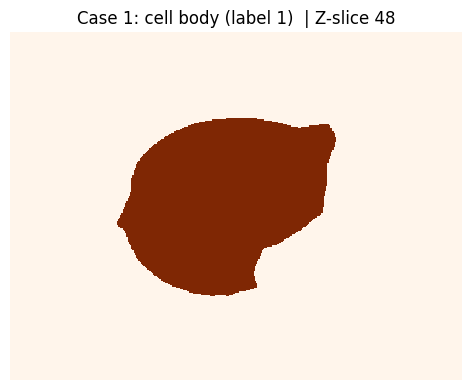

In [57]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(label_case1[mid_z], cmap='Oranges', interpolation='nearest', vmin=0, vmax=1)
ax.set_title(f'Case 1: cell body (label 1)  | Z-slice {mid_z}')
ax.axis('off')
plt.tight_layout()
plt.show()

## Case 2 — Two-compartment: nuclei + cell body

Assign **label 1** to the nuclei (channel 0) and **label 2** to the cell body (channel 1).
Both compartments are computed in a single `minkowski_tensors_from_label_image()` call.

Where the channels overlap (nuclei inside cell body), the nucleus label takes priority.

In [58]:
label_case2 = np.zeros_like(nuclei_mask, dtype=int)
label_case2[cell_mask > 0]   = 2  # cell body → label 2
label_case2[nuclei_mask > 0] = 1  # nuclei override → label 1

results_case2 = pk.minkowski_tensors_from_label_image(label_case2, compute="all")

print('Case 2 — two compartments')
for label, name in [(1, 'nuclei (combined)'), (2, 'cell body')]:
    r = results_case2[label]
    print(f'  Label {label} ({name}):')
    print(f'    Volume (w000):          {r["w000"] * voxel_size_um**3:.1f} µm³')
    print(f'    Surface area (w100):    {r["w100"] * voxel_size_um**2:.1f} µm²')
    print(f'    Anisotropy (w020_beta): {r["w020_beta"]:.4f}')

Case 2 — two compartments
  Label 1 (nuclei (combined)):
    Volume (w000):          109.7 µm³
    Surface area (w100):    145.0 µm²
    Anisotropy (w020_beta): 0.1179
  Label 2 (cell body):
    Volume (w000):          2986.9 µm³
    Surface area (w100):    644.4 µm²
    Anisotropy (w020_beta): 0.2800


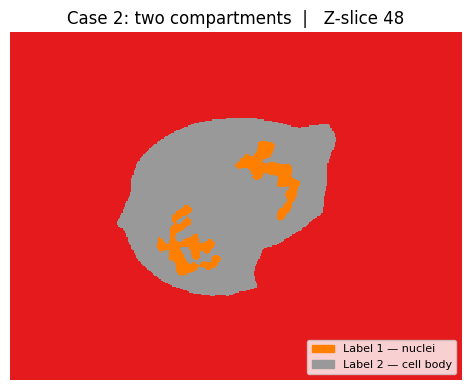

In [59]:
cmap2 = plt.colormaps['Set1'].resampled(3)  # 0=background, 1=nuclei, 2=cell
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(label_case2[mid_z], cmap=cmap2, vmin=0, vmax=2, interpolation='nearest')
patches = [
    mpatches.Patch(color=cmap2(1), label='Label 1 — nuclei'),
    mpatches.Patch(color=cmap2(2), label='Label 2 — cell body'),
]
ax.legend(handles=patches, loc='lower right', fontsize=8)
ax.set_title(f'Case 2: two compartments  |   Z-slice {mid_z}')
ax.axis('off')
plt.tight_layout()
plt.show()

## Case 3 — Per-nucleus: individual nucleus morphometry

The nuclei channel contains **3 connected components**.
Using `scipy.ndimage.label` we assign each nucleus a unique label, then compute per-nucleus Minkowski tensors.

The dividing daughter nuclei are expected to be more **elongated** (lower `w020_beta`) than a resting nucleus.

In [60]:
label_case3, n_nuclei = ndimage.label(nuclei_mask)
print(f'Found {n_nuclei} nuclei')

results_case3 = pk.minkowski_tensors_from_label_image(label_case3, compute="all")

print(f'\n{"Nucleus":<10} {"Volume (µm³)":>14} {"Area (µm²)":>12} {"beta (anisotropy)":>18}')
print('-' * 58)
for label, r in sorted(results_case3.items()):
    print(f'{label:<10} {r["w000"] * voxel_size_um**3:>14.2f} {r["w100"] * voxel_size_um**2:>12.2f} {r["w020_beta"]:>18.4f}')

Found 3 nuclei

Nucleus      Volume (µm³)   Area (µm²)  beta (anisotropy)
----------------------------------------------------------
1                   55.81        76.04             0.1935
2                   27.10        35.63             0.1439
3                   26.82        33.28             0.1514


Objects 2 and 3 appear to be part of the same structure segmented as two separate components — their Z ranges (40–72 and 78–110) suggest they occupy different axial regions of what may be a single group of sister chromatids. The table below shows Z coverage per component; adjust `mid_z` in the visualisation above to inspect each one.

| Object | Z range | Span | Voxels |
|--------|---------|------|--------|
| 1 | 38–107 | 70 slices | 44,131 |
| 2 | 40–72 | 33 slices | 21,420 |
| 3 | 78–110 | 33 slices | 21,195 |

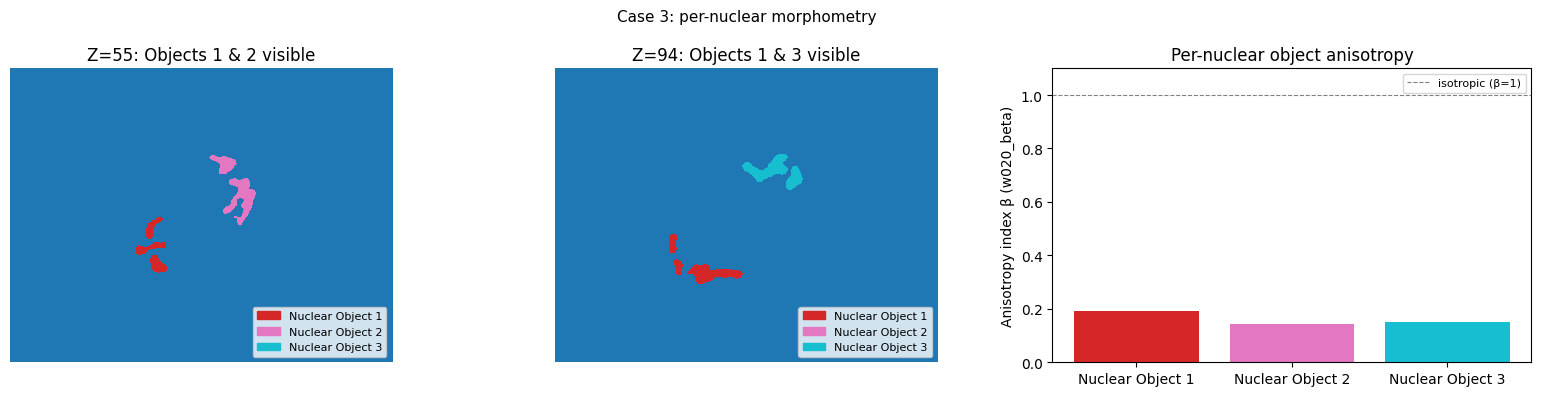

In [61]:
cmap3 = plt.colormaps['tab10'].resampled(n_nuclei + 1)

# Objects 1, 2 and 3 do not all occupy the same Z-range (see table above).
# Two slices are shown: one where Objects 1 & 2 are visible (Z=55),
# and one where Objects 1 & 3 are visible (Z=94).
z_obj12 = 55   # mid-Z of Object 2 (range 40-72); Object 1 also present
z_obj13 = 94   # mid-Z of Object 3 (range 78-110); Object 1 also present

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(label_case3[z_obj12], cmap=cmap3, vmin=0, vmax=n_nuclei, interpolation='nearest')
axes[0].set_title(f'Z={z_obj12}: Objects 1 & 2 visible')
axes[0].axis('off')

axes[1].imshow(label_case3[z_obj13], cmap=cmap3, vmin=0, vmax=n_nuclei, interpolation='nearest')
axes[1].set_title(f'Z={z_obj13}: Objects 1 & 3 visible')
axes[1].axis('off')

patches3 = [mpatches.Patch(color=cmap3(i), label=f'Nuclear Object {i}') for i in range(1, n_nuclei + 1)]
for ax in axes[:2]:
    ax.legend(handles=patches3, loc='lower right', fontsize=8)

# Anisotropy bar chart
labels_bar = [f'Nuclear Object {i}' for i in sorted(results_case3)]
betas      = [results_case3[i]['w020_beta'] for i in sorted(results_case3)]
colors     = [cmap3(i) for i in sorted(results_case3)]
axes[2].bar(labels_bar, betas, color=colors)
axes[2].axhline(1.0, color='grey', linestyle='--', linewidth=0.8, label='isotropic (β=1)')
axes[2].set_ylabel('Anisotropy index β (w020_beta)')
axes[2].set_ylim(0, 1.1)
axes[2].set_title('Per-nuclear object anisotropy')
axes[2].legend(fontsize=8)

plt.suptitle('Case 3: per-nuclear morphometry', fontsize=11)
plt.tight_layout()
plt.show()

## Case 3b — Merging segmented components: Minkowski tensor additivity

If objects 2 and 3 belong to the same structure, we can merge them into a single label and recompute.

Minkowski tensors have a key additivity property for **disjoint** objects:

| Quantity | Additive? | Notes |
|----------|-----------|-------|
| `w000`, `w100`, `w200`, `w300` | ✅ yes | Scalar functionals sum directly |
| `w020` … `w202` (tensor matrices) | ✅ yes | W_merged = W_2 + W_3 |
| `_trace` | ✅ yes | Trace is linear |
| `_eigvals`, `_eigvecs` | ❌ no | Eigensystem of sum ≠ sum of eigensystems |
| `_beta` (anisotropy index) | ❌ no | Must recompute from merged tensor |
| `_trace_ratio` | ❌ no | Ratio — must recompute |

The correct approach is to **re-label** and re-run rather than combine derived quantities.

In [62]:
# Merge objects 2 and 3 into a single label
label_merged = label_case3.copy()
label_merged[label_case3 == 3] = 2  # relabel object 3 → 2

# Use center=None so all objects share the same reference frame —
# required for tensor matrix additivity (per-centroid centering shifts
# each object to its own origin, making position-dependent tensors
# non-comparable across objects)
kw = dict(compute="all", center=None)
results_ind = pk.minkowski_tensors_from_label_image(label_case3, **kw)
results_mrg = pk.minkowski_tensors_from_label_image(label_merged, **kw)

r2, r3, rm = results_ind[2], results_ind[3], results_mrg[2]

vs2 = voxel_size_um**2
vs3 = voxel_size_um**3

print("Additivity check (objects 2 + 3 merged), center=None:")
print(f"  w000 (volume): {r2['w000']*vs3:.2f} + {r3['w000']*vs3:.2f} = {(r2['w000']+r3['w000'])*vs3:.2f} µm³  |  merged: {rm['w000']*vs3:.2f} µm³")
print(f"  w100 (area):   {r2['w100']*vs2:.2f} + {r3['w100']*vs2:.2f} = {(r2['w100']+r3['w100'])*vs2:.2f} µm²  |  merged: {rm['w100']*vs2:.2f} µm²")
print(f"  w300 (Euler):  {r2['w300']:.4f} + {r3['w300']:.4f} = {r2['w300']+r3['w300']:.4f}  |  merged: {rm['w300']:.4f}")
print(f"  w102 matrix:   max|W2+W3 - W_merged| = {abs(r2['w102']+r3['w102']-rm['w102']).max():.2e}  (~0 = additive)")
print()
print("Non-additive — must recompute from merged tensor:")
print(f"  w102_beta obj2:   {r2['w102_beta']:.4f}")
print(f"  w102_beta obj3:   {r3['w102_beta']:.4f}")
print(f"  sum:              {r2['w102_beta']+r3['w102_beta']:.4f}")
print(f"  w102_beta merged: {rm['w102_beta']:.4f}  <-- differs from sum")

Additivity check (objects 2 + 3 merged), center=None:
  w000 (volume): 27.10 + 26.82 = 53.92 µm³  |  merged: 53.92 µm³
  w100 (area):   35.63 + 33.28 = 68.92 µm²  |  merged: 68.92 µm²
  w300 (Euler):  4.1888 + 4.1888 = 8.3776  |  merged: 8.3776
  w102 matrix:   max|W2+W3 - W_merged| = 4.55e-13  (~0 = additive)

Non-additive — must recompute from merged tensor:
  w102_beta obj2:   0.7912
  w102_beta obj3:   0.7680
  sum:              1.5592
  w102_beta merged: 0.8633  <-- differs from sum


## Summary

The same binary segmentation yields fundamentally different measurements depending on how labels are assigned:

| Case | Input | `minkowski_tensors_from_label_image` call | Output |
|------|-------|------------------------------------------|--------|
| 1 | One binary mask | `(cell_mask)` | One result — whole cell |
| 2 | Two binary masks combined | `(label_case2)` with labels 1 & 2 | Two results — per channel |
| 3 | Nuclei mask → `scipy.ndimage.label` | `(label_case3)` | N results — per nucleus |

Key observations:
- **Case 1 vs Case 3**: same nuclei binary mask, but Case 1 treats all nuclei as one object (measures total nuclear volume/shape) while Case 3 resolves individual nuclear object.
- **Case 2**: per-compartment comparison shows that nuclei and cell body have different anisotropy signatures.